#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 4: Detección de Anomalías  </center>

# Introducción

En la siguiente actividad se trabajará en la detección de anomalías sobre redes de computadoras a partir de datos de tráfico. El objetivo será construir un modelo capaz de distinguir entre malas conexiones o ataques, y buenas conexiones, llamadas normales. Para esto se utilizará una parte del conjunto [KDD Cup'99](https://scikit-learn.org/stable/datasets/real_world.html#kddcup99-dataset) pensada para evaluar métodos de detección de anomalías.

Para los problemas de detección de anomalías generalmente no se cuenta con datos etiquetados para entrenar un detector. Por su definición las anomalías son eventos raros y por lo tanto poco frecuentes, lo que dificulta el etiquetado. Es por esto que este tipo de tareas generalmente son no supervisadas.

El enfoque más habitual para implementar soluciones para este tipo de problemas, es crear un modelo base a partir de un conjunto de datos "normales", es decir de los cuales se tenga cierta certeza de que todos fueron adquiridos en una situación normal. Luego, en producción se detectarán como datos anómalos todos aquellos que no se ajusten a este modelo. Para saber el grado de ajuste de los datos se debe seleccionar un punto de operación, es decir, determinar cuándo un dato se considera anómalo. En un ejemplo real, el cliente primero debería proporcionar una cantidad considerable de datos que representen el comportamiento normal de su sistema. Luego que se tiene el mejor modelo posible de estos datos, junto con el cliente, que es el que conoce su sistema, se debe determinar el punto de operación a partir del compromiso entre detectar la mayor cantidad de anomalías y obtener la menor cantidad de falsas alarmas posibles.

Para hacer investigación en la detección de anomalías, existen conjuntos de datos como el que se trabajará en esta actividad que si tienen etiquetas. Generalmente estas se obtienen provocando fallas y/o ataques intencionales a un sistema que se encuentra funcionando de manera normal. En esta actividad se separará el conjunto de entrenamiento en dos partes. La primera con una gran proporción de datos etiquetados como normales, simulará ser el conjunto que el cliente nos proporciona para entrenar nuestro modelo. El otro conjunto tendrá datos etiquetados como normales y como anómalos, que se utilizará para definir el punto de operación. Asimismo, se tendrá un conjunto de test asociados a este problema para evaluar la puesta en producción del modelo.

## Objetivos


*   Abordar un problema de detección de anomalías, y ver las diferencias con un problema de clasificación convencional.
*   Trabajar con algoritmos de aprendizaje no supervisado.
*   Crear detectores compatibles con los *pipelines* de *scikit-learn*.


# Formas de trabajo

### Opción 1: Trabajar localmente

# Descargar los datos en su máquina personal y trabajar en su propio ambiente de desarrollo.

`conda activate TAA-py311`              
`jupyter-notebook`    

Los paquetes faltantes se pueden instalar desde el notebook haciendo:     
` !pip install paquete_faltante`

### Opción 2:  Trabajar en *Colab*.

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/TAA-fing/TAA-2026/blob/main/talleres/taller4_anomalias.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Ejecutar en Google Colab</a>
  </td>
</table>

Se puede trabajar en Google Colab. Para ello es necesario contar con una cuenta de **google drive** y ejecutar un notebook almacenado en dicha cuenta. De lo contrario, no se conservarán los cambios realizados en la sesión. En caso de ya contar con una cuenta, se puede abrir el notebook y luego ir a `Archivo-->Guardar una copia en drive`.

# Datos

### Parte 1 - Levantar los Datos

#### Conjunto de Entrenamiento

El conjunto de datos [KDD Cup'99](https://scikit-learn.org/stable/datasets/real_world.html#kddcup99-dataset) contiene un conjunto de datos de tráfico de red que incluye tráfico normal y malicioso. El conjunto de datos para entrenamiento contiene 100655 instancias donde cada una cuenta con 41 características entre las que se encuentran la duración de la conexión, los tipos de protocolo, los tipos de servicios, entre otros. Por más información sobre el contenido de las características haga clic [aquí](http://kdd.ics.uci.edu/databases/kddcup99/task.html). Además, se cuenta con la columna *'labels'* que indica si el dato es normal o, de no serlo, indica el tipo de anomalía.

#### Ejercicios:

 - Ejecute la siguientes celdas para levantar el conjunto de datos de entrenamiento.
 - Observar la cantidad de muestras por tipo.
 - Determinar la relación entre datos normales y anómalos.  

In [1]:
import pandas as pd
import numpy as np
import time
from sklearn.datasets import fetch_kddcup99

#Se obtienen los datos en formato de diccionario
KDDSA = fetch_kddcup99(subset='SA', as_frame=True, random_state=42)

#A partir del diccionario se crea un Dataframe con los datos
df = pd.DataFrame(data=KDDSA.frame.values, columns=KDDSA.frame.columns)

#Se estandariza el formato de los datos en el Dataframe
types = [float, str, str,str, float, float, str, float, float, float, float, str, float, float,float, float, float, float, float, float, str, str,
         float, float, float, float,float, float, float, float,float, float, float, float, float, float, float,float, float, float, float, str]

columns = df.columns
for i in range(len(columns)):
    df[columns[i]] = df[columns[i]].astype(types[i])
    if types[i] == str:
        df[columns[i]]= df[columns[i]].str.replace("b'", "")
        df[columns[i]]= df[columns[i]].str.replace("'", "")

#Visualizo
df.head(20)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0.0,tcp,http,SF,181.0,5450.0,0,0.0,0.0,0.0,...,9.0,1.0,0.0,0.11,0.00,0.0,0.0,0.0,0.0,normal.
1,0.0,tcp,http,SF,239.0,486.0,0,0.0,0.0,0.0,...,19.0,1.0,0.0,0.05,0.00,0.0,0.0,0.0,0.0,normal.
2,0.0,tcp,http,SF,235.0,1337.0,0,0.0,0.0,0.0,...,29.0,1.0,0.0,0.03,0.00,0.0,0.0,0.0,0.0,normal.
3,0.0,tcp,http,SF,219.0,1337.0,0,0.0,0.0,0.0,...,39.0,1.0,0.0,0.03,0.00,0.0,0.0,0.0,0.0,normal.
4,0.0,tcp,http,SF,217.0,2032.0,0,0.0,0.0,0.0,...,49.0,1.0,0.0,0.02,0.00,0.0,0.0,0.0,0.0,normal.
5,0.0,tcp,http,SF,217.0,2032.0,0,0.0,0.0,0.0,...,59.0,1.0,0.0,0.02,0.00,0.0,0.0,0.0,0.0,normal.
6,0.0,tcp,http,SF,212.0,1940.0,0,0.0,0.0,0.0,...,69.0,1.0,0.0,1.00,0.04,0.0,0.0,0.0,0.0,normal.
7,0.0,tcp,http,SF,159.0,4087.0,0,0.0,0.0,0.0,...,79.0,1.0,0.0,0.09,0.04,0.0,0.0,0.0,0.0,normal.
8,0.0,tcp,http,SF,210.0,151.0,0,0.0,0.0,0.0,...,89.0,1.0,0.0,0.12,0.04,0.0,0.0,0.0,0.0,normal.
9,0.0,tcp,http,SF,212.0,786.0,0,0.0,0.0,1.0,...,99.0,1.0,0.0,0.12,0.05,0.0,0.0,0.0,0.0,normal.


In [2]:
print(df.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'labels'],
      dtype='object')


In [3]:
print(df["labels"].unique())

['normal.' 'smurf.' 'neptune.' 'ipsweep.' 'portsweep.' 'warezclient.'
 'buffer_overflow.' 'back.' 'pod.' 'satan.' 'land.' 'teardrop.']


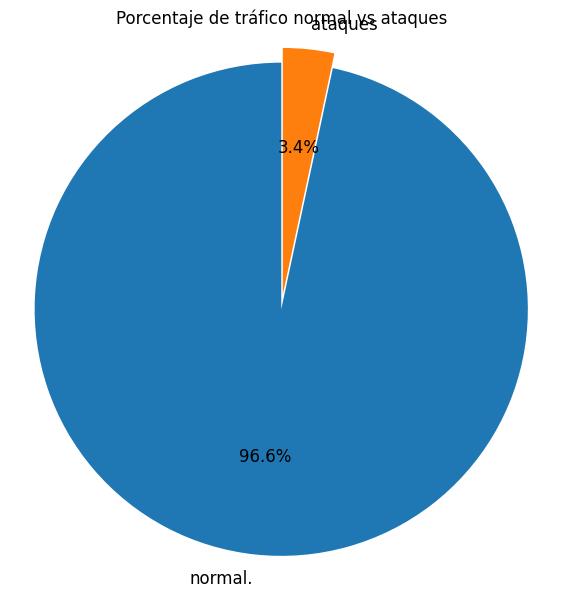

Normal: 96.64%
Ataques: 3.36%


In [4]:
import matplotlib.pyplot as plt

# contar normal vs resto
normal_count = (df["labels"] == "normal.").sum()
attack_count = (df["labels"] != "normal.").sum()

counts = [normal_count, attack_count]
labels = ["normal.", "ataques"]
explode = [0.03, 0.03]

plt.figure(figsize=(7, 7))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    textprops={'fontsize': 12}
)
plt.title("Porcentaje de tráfico normal vs ataques")
plt.axis("equal")
plt.show()

print(f"Normal: {normal_count / len(df) * 100:.2f}%")
print(f"Ataques: {attack_count / len(df) * 100:.2f}%")

In [5]:
counts = df["labels"].value_counts()
percentages = df["labels"].value_counts(normalize=True) * 100

summary = (
    df["labels"]
    .value_counts()
    .rename_axis("tipo")
    .reset_index(name="cantidad")
)

summary["porcentaje"] = summary["cantidad"] / len(df) * 100
summary["porcentaje"] = summary["porcentaje"].round(2)

print(summary)

                tipo  cantidad  porcentaje
0            normal.     97278       96.64
1             smurf.      2409        2.39
2           neptune.       898        0.89
3              back.        15        0.01
4             satan.        15        0.01
5           ipsweep.        10        0.01
6          teardrop.         9        0.01
7         portsweep.         8        0.01
8       warezclient.         8        0.01
9               pod.         3        0.00
10  buffer_overflow.         1        0.00
11             land.         1        0.00


#### Conjunto de Test

Este problema tiene disponible un conjunto de datos para Test, estos se pueden encontar [aquí](https://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html).

#### Ejercicios:

 - Descargar y levantar los datos de Test.
 - Separar los datos de las etiquetas.

In [6]:
# pip install wget

In [7]:
#start
# start = time.time()

#Importo wget
# import wget

#Descargo los datos de Test
#wget.download('http://kdd.ics.uci.edu/databases/kddcup99/corrected.gz', 'data/data_taller4/corrected.gz')

#end
#end = time.time()
#print(np.round(end - start,3), 'segundos')

In [8]:
#Levanto los datos de Test
test_data = pd.read_csv('data/data_taller4/corrected.gz', header=None)

test_data.columns = columns

#Se estandariza el formato de los datos en el Dataframe
types = [float, str, str,str, float, float, str, float, float, float, float, str, float, float,float, float, float, float, float, float, str, str,
         float, float, float, float,float, float, float, float,float, float, float, float, float, float, float,float, float, float, float, str]

for i in range(len(columns)):
    test_data[columns[i]] = test_data[columns[i]].astype(types[i])

test_data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,254.0,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.
1,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,254.0,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.
2,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,254.0,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.
3,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,254.0,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,snmpgetattack.
4,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,254.0,1.0,0.01,0.01,0.0,0.0,0.0,0.0,0.0,snmpgetattack.


In [9]:
counts = test_data["labels"].value_counts()
percentages = test_data["labels"].value_counts(normalize=True) * 100

summary = (
    test_data["labels"]
    .value_counts()
    .rename_axis("tipo")
    .reset_index(name="cantidad")
)

summary["porcentaje"] = summary["cantidad"] / len(test_data) * 100
summary["porcentaje"] = summary["porcentaje"].round(2)

print(summary)

                tipo  cantidad  porcentaje
0             smurf.    164091       52.76
1            normal.     60593       19.48
2           neptune.     58001       18.65
3     snmpgetattack.      7741        2.49
4          mailbomb.      5000        1.61
5      guess_passwd.      4367        1.40
6         snmpguess.      2406        0.77
7             satan.      1633        0.53
8       warezmaster.      1602        0.52
9              back.      1098        0.35
10            mscan.      1053        0.34
11          apache2.       794        0.26
12     processtable.       759        0.24
13            saint.       736        0.24
14        portsweep.       354        0.11
15          ipsweep.       306        0.10
16       httptunnel.       158        0.05
17              pod.        87        0.03
18             nmap.        84        0.03
19  buffer_overflow.        22        0.01
20         multihop.        18        0.01
21            named.        17        0.01
22         

In [10]:
y_test = test_data['labels']
X_test = test_data.drop(columns=['labels'])
display(X_test.head())
display(y_test.head())

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,255.0,254.0,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0
1,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,255.0,254.0,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0
2,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,255.0,254.0,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0
3,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,255.0,254.0,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0
4,0.0,udp,private,SF,105.0,146.0,0,0.0,0.0,0.0,...,255.0,254.0,1.0,0.01,0.01,0.0,0.0,0.0,0.0,0.0


0           normal.
1           normal.
2           normal.
3    snmpgetattack.
4    snmpgetattack.
Name: labels, dtype: object

### Parte 2 - Preparar Conjuntos

#### Ejercicios:

Manteniendo el orden de los datos de Entrenamiento:

 - Separar las primeras 90000 muestras para entrenamiento con sus respectivas etiquetas. Estos deberían estar etiquetados como *normales*.
 - Separar las restantes muestras y sus respectivas etiquetas para validación.  Este conjunto permitirá fijar el punto de operación del modelo.

In [11]:
# Separar las primeras 90000 muestras para entrenamiento (solo normales)
X_train_normal = df.iloc[:90000].drop(columns=['labels'])
y_train_normal = df.iloc[:90000]['labels']

# Las restantes muestras para validación
X_val = df.iloc[90000:].drop(columns=['labels'])
y_val = df.iloc[90000:]['labels']

# Verificar que las etiquetas de entrenamiento sean todas 'normal.'
print(f"All training labels are 'normal.': {(y_train_normal == 'normal.').all()}")

display(X_train_normal.head())
display(y_train_normal.head())
display(X_val.head())
display(y_val.head())

All training labels are 'normal.': True


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0.0,tcp,http,SF,181.0,5450.0,0,0.0,0.0,0.0,...,9.0,9.0,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0
1,0.0,tcp,http,SF,239.0,486.0,0,0.0,0.0,0.0,...,19.0,19.0,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0
2,0.0,tcp,http,SF,235.0,1337.0,0,0.0,0.0,0.0,...,29.0,29.0,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0
3,0.0,tcp,http,SF,219.0,1337.0,0,0.0,0.0,0.0,...,39.0,39.0,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0
4,0.0,tcp,http,SF,217.0,2032.0,0,0.0,0.0,0.0,...,49.0,49.0,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0


0    normal.
1    normal.
2    normal.
3    normal.
4    normal.
Name: labels, dtype: object

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
90000,2715.0,udp,other,SF,147.0,105.0,0,0.0,0.0,0.0,...,255.0,1.0,0.00,0.84,1.0,0.0,0.0,0.0,0.0,0.0
90001,2715.0,udp,other,SF,147.0,105.0,0,0.0,0.0,0.0,...,255.0,1.0,0.00,0.84,1.0,0.0,0.0,0.0,0.0,0.0
90002,0.0,udp,other,SF,147.0,0.0,0,0.0,0.0,0.0,...,255.0,1.0,0.00,0.84,1.0,0.0,0.0,0.0,0.0,0.0
90003,2715.0,udp,other,SF,147.0,105.0,0,0.0,0.0,0.0,...,255.0,1.0,0.00,0.84,1.0,0.0,0.0,0.0,0.0,0.0
90004,2708.0,udp,other,SF,147.0,105.0,0,0.0,0.0,0.0,...,255.0,2.0,0.01,0.84,1.0,0.0,0.0,0.0,0.0,0.0


90000    normal.
90001    normal.
90002    normal.
90003    normal.
90004    normal.
Name: labels, dtype: object

In [12]:
#Verifico las anomalias presentes en cada conjunto
print('Tipo de datos en Entrenamiento:\n',np.unique(y_train_normal))
print('Tipo de datos en Validacion:\n',np.unique(y_val))
print('Tipo de datos en Test:\n',np.unique(y_test))

Tipo de datos en Entrenamiento:
 ['normal.']
Tipo de datos en Validacion:
 ['back.' 'buffer_overflow.' 'ipsweep.' 'land.' 'neptune.' 'normal.' 'pod.'
 'portsweep.' 'satan.' 'smurf.' 'teardrop.' 'warezclient.']
Tipo de datos en Test:
 ['apache2.' 'back.' 'buffer_overflow.' 'ftp_write.' 'guess_passwd.'
 'httptunnel.' 'imap.' 'ipsweep.' 'land.' 'loadmodule.' 'mailbomb.'
 'mscan.' 'multihop.' 'named.' 'neptune.' 'nmap.' 'normal.' 'perl.' 'phf.'
 'pod.' 'portsweep.' 'processtable.' 'ps.' 'rootkit.' 'saint.' 'satan.'
 'sendmail.' 'smurf.' 'snmpgetattack.' 'snmpguess.' 'sqlattack.'
 'teardrop.' 'udpstorm.' 'warezmaster.' 'worm.' 'xlock.' 'xsnoop.'
 'xterm.']


El código anterior muestra la cantidad de clases presente en cada conjunto. Verifique que en el conjunto de Entrenamiento solo hay muestras normales.

Es importante tener en cuenta que los datos de Test presentan una distribución de probabilidad diferente a la de los datos de entrenamiento y validación, de hecho, contienen tipos específicos de ataques. Este aspecto es crucial para hacer la tarea de detección de anomalías más realista.

Los ataques informáticos pueden ser clasificados en diferentes categorías, las cuales se definen en función de su objetivo y método de ejecución. Es usual, categorizar los ataques en cuatro tipos principales:

* **DoS**: Tienen como objetivo abrumar un sistema o red con una gran cantidad de tráfico, lo que puede resultar en una disminución o pérdida total del servicio , e.g. syn flood;
* **R2L**: Buscan obtener acceso no autorizado a un sistema desde una máquina remota, e.g. adivinar la contraseña;
* **U2R**: Buscan obtener acceso no autorizado a privilegios de superusuario local o raíz., e.g., various ''buffer overflow'' attacks;
* **probing**: Consisten en la vigilancia y exploración de, por ejemplo, puertos y/o servicios en busca de vulnerabilidades que puedan ser explotadas posteriormente.

A continuación, se otorga un diccionario de correspondencia entre las anomalías y la categoría correspondiente.

In [13]:
# Se define un diccionario con la correspondencia entre la anomalía y la categoría
attack_dict = {
    'normal.': 'normal',

    'back.': 'DoS',
    'land.': 'DoS',
    'neptune.': 'DoS',
    'pod.': 'DoS',
    'smurf.': 'DoS',
    'teardrop.': 'DoS',
    'mailbomb.': 'DoS',
    'apache2.': 'DoS',
    'processtable.': 'DoS',
    'udpstorm.': 'DoS',

    'ipsweep.': 'Probe',
    'nmap.': 'Probe',
    'portsweep.': 'Probe',
    'satan.': 'Probe',
    'mscan.': 'Probe',
    'saint.': 'Probe',

    'ftp_write.': 'R2L',
    'guess_passwd.': 'R2L',
    'imap.': 'R2L',
    'multihop.': 'R2L',
    'phf.': 'R2L',
    'spy.': 'R2L',
    'warezclient.': 'R2L',
    'warezmaster.': 'R2L',
    'sendmail.': 'R2L',
    'named.': 'R2L',
    'snmpgetattack.': 'R2L',
    'snmpguess.': 'R2L',
    'xlock.': 'R2L',
    'xsnoop.': 'R2L',
    'worm.': 'R2L',

    'buffer_overflow.': 'U2R',
    'loadmodule.': 'U2R',
    'perl.': 'U2R',
    'rootkit.': 'U2R',
    'httptunnel.': 'U2R',
    'ps.': 'U2R',
    'sqlattack.': 'U2R',
    'xterm.': 'U2R'
}

Antes de finalizar se deberán cambiar las etiquetas de los datos en todos los conjuntos a 0 y 1. Siendo 0 la etiqueta de la clase normal y 1 la etiqueta de la clase anómala.

#### Objetivos:
 - Cambiar las etiquetas de los datos en todos los conjuntos a 0 y 1.

**Comentario**: Se sugiere en alguna variable distinta conservar los valores originales.

In [14]:
# Conservar etiquetas originales
y_train_normal_orig = y_train_normal.copy()
y_val_orig = y_val.copy()
y_test_orig = y_test.copy()

# Convertir a 0 (normal) y 1 (anomalía)
y_train_normal = (y_train_normal != 'normal.').astype(int)
y_val = (y_val != 'normal.').astype(int)
y_test = (y_test != 'normal.').astype(int)

print('Valores únicos en y_train_normal:', np.unique(y_train_normal))
print('Valores únicos en y_val:', np.unique(y_val))
print('Valores únicos en y_test:', np.unique(y_test))

Valores únicos en y_train_normal: [0]
Valores únicos en y_val: [0 1]
Valores únicos en y_test: [0 1]


### Parte 3 - Preprocesar y Visualizar los Datos

Una vez armados los conjuntos de datos, se espera que se realice una exploración y análisis de los mismos. Conforme a lo anterior, se espera que se implemente  un pipeline de preprocesamiento adecuado para los datos en cuestión.

#### Ejercicios:

 - Analizar y visualizar los datos.
 - Implementar un **pipeline** que realice los los preprocesamientos que considere necesarios.

In [15]:
# Tipos de datos por columna
print("--- Tipos de Datos ---")
print(df.dtypes)

print("\n--- Valores Nulos por Columna ---")
# Cantidad de nulos por columna
print(df.isnull().sum())

--- Tipos de Datos ---
duration                       float64
protocol_type                   object
service                         object
flag                            object
src_bytes                      float64
dst_bytes                      float64
land                            object
wrong_fragment                 float64
urgent                         float64
hot                            float64
num_failed_logins              float64
logged_in                       object
num_compromised                float64
root_shell                     float64
su_attempted                   float64
num_root                       float64
num_file_creations             float64
num_shells                     float64
num_access_files               float64
num_outbound_cmds              float64
is_host_login                   object
is_guest_login                  object
count                          float64
srv_count                      float64
serror_rate                    float64
sr

In [16]:
# Media y Varianza para las columnas numéricas
print("--- Resumen estadístico de columnas numéricas ---")
stats_df = pd.DataFrame({
    'Media': df.mean(numeric_only=True),
    'Varianza': df.var(numeric_only=True)
})
display(stats_df)

# Valores únicos para las columnas categóricas
print("\n--- Valores únicos de columnas categóricas ---")
for col in df.select_dtypes(include=['object']).columns:
    unique_vals = df[col].unique()
    print(f"{col}: {unique_vals[:10]}..." if len(unique_vals) > 10 else f"{col}: {unique_vals}")

--- Resumen estadístico de columnas numéricas ---


,Media,Varianza
duration,209.388644,1.787000e+06
src_bytes,1149.042621,1.132565e+09
dst_bytes,3272.463633,1.365117e+09
wrong_fragment,0.000298,8.344533e-04
urgent,0.000030,8.941434e-05
hot,0.044151,7.361634e-01
num_failed_logins,0.000179,4.172391e-04
num_compromised,0.027728,1.582754e+01
root_shell,0.000229,2.284534e-04
su_attempted,0.000169,2.880872e-04



--- Valores únicos de columnas categóricas ---
protocol_type: ['tcp' 'udp' 'icmp']
service: ['http' 'smtp' 'finger' 'domain_u' 'auth' 'telnet' 'ftp' 'eco_i' 'ntp_u'
 'ecr_i']...
flag: ['SF' 'S1' 'REJ' 'S2' 'S0' 'RSTO' 'S3' 'OTH' 'RSTR']
land: ['0' '1']
logged_in: ['1' '0']
is_host_login: ['0']
is_guest_login: ['0' '1']
labels: ['normal.' 'smurf.' 'neptune.' 'ipsweep.' 'portsweep.' 'warezclient.'
 'buffer_overflow.' 'back.' 'pod.' 'satan.']...


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline

# Identificamos columnas por tipo
cat_cols = ['protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_host_login', 'is_guest_login']
num_cols = [col for col in X_train_normal.columns if col not in cat_cols]

# Definimos el preprocesador base
# El StandardScaler se aplica a las variables numéricas
preprocessor_base = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# Creamos el pipeline de preprocesamiento final
preprocessing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_base),
    ('selector', VarianceThreshold(threshold=0)) # Elimina columnas con varianza 0
])

# Ajustamos con los datos de entrenamiento (solo normales)
preprocessing_pipeline.fit(X_train_normal)

# Transformamos los conjuntos
X_train_prep = preprocessing_pipeline.transform(X_train_normal)
X_val_prep = preprocessing_pipeline.transform(X_val)
X_test_prep = preprocessing_pipeline.transform(X_test)

print(f"Dimensiones originales: {X_train_normal.shape}")
print(f"Dimensiones tras Preprocesamiento (Scaling + OHE + Variance): {X_train_prep.shape}")

Dimensiones originales: (90000, 41)
Dimensiones tras Preprocesamiento (Scaling + OHE + Variance): (90000, 75)


In [18]:
import pandas as pd
import numpy as np

# Obtenemos los nombres de las columnas después del preprocesamiento
# Nota: usamos get_feature_names_out() del pipeline
feature_names = preprocessing_pipeline.get_feature_names_out()

# Creamos un DataFrame temporal con los datos de entrenamiento procesados
df_prep = pd.DataFrame(X_train_prep, columns=feature_names)

# Calculamos media y varianza
stats_prep = pd.DataFrame({
    'Media': df_prep.mean(),
    'Varianza': df_prep.var()
})

print(f"--- Resumen estadístico de las {df_prep.shape[1]} columnas procesadas ---")
# Mostramos las primeras y últimas filas para no saturar
display(stats_prep.head(10))
display(stats_prep.tail(10))

# Verificación rápida
print(f"\nMedia máxima: {stats_prep['Media'].max():.2e}")
print(f"Media mínima: {stats_prep['Media'].min():.2e}")
print(f"Varianza promedio: {stats_prep['Varianza'].mean():.2f}")

--- Resumen estadístico de las 75 columnas procesadas ---


,Media,Varianza
num__duration,2.021099e-17,1.000011
num__src_bytes,-2.052679e-18,1.000011
num__dst_bytes,-2.526374e-18,1.000011
num__urgent,-1.578984e-19,1.000011
num__hot,-2.779012e-17,1.000011
num__num_failed_logins,2.171103e-18,1.000011
num__num_compromised,-1.736882e-18,1.000011
num__root_shell,7.579123e-18,1.000011
num__su_attempted,-2.763222e-18,1.000011
num__num_root,2.526374e-18,1.000011


,Media,Varianza
cat__flag_S1,0.000556,0.000555
cat__flag_S2,0.000156,0.000156
cat__flag_S3,0.000078,0.000078
cat__flag_SF,0.938689,0.057553
cat__land_0,0.999989,0.000011
cat__land_1,0.000011,0.000011
cat__logged_in_0,0.286989,0.204629
cat__logged_in_1,0.713011,0.204629
cat__is_guest_login_0,0.996033,0.003951
cat__is_guest_login_1,0.003967,0.003951



Media máxima: 1.00e+00
Media mínima: -6.67e-16
Varianza promedio: 0.45


# Detección de anomalías

Si bien *scikit-learn* proporciona algunas herramientas para la detección de anomalías, esta actividad se centra en la utilización de algoritmos no supervisados generalmente pensados para otras tareas como: reducción de la dimensionalidad, y/o *clustering*. Específicamente se trabajará con: PCA, *K-Means*, y *Gaussian Mixture Model* (GMM).

## PCA


El análisis de componentes principales (**PCA**) es una técnica de reducción de la dimensionalidad que permite representar los datos en un espacio de menor dimensión manteniendo la mayor cantidad posible de información.

En la *Parte 1* se deberá seleccionar la cantidad de componentes principales que se utilizarán en el modelo. También, se sugiere utilizar esta técnica como una herramienta de visualización de datos.

Luego, en la *Parte 2* se implementa un detector de anomalías utilizando esta técnica.

### Parte 1


#### Ejercicios:

 - Aplicar PCA sobre los datos de entrenamiento y graficar como varía el porcentaje de la varianza total en función de la cantidad de componentes principales (CPs). Se sugiere ver la sección *Choosing the Right Number of Dimensions* del capítulo 8 del libro.
 - Determinar la cantidad de CPs de manera de mantener el *99%* de la varianza de los datos.
 - Utilizando PCA visualice los datos en dos o tres dimensiones. ¿Logra identificar clusters? *Para esta parte puede resultar útil comparar según la proyeccion de datos Normales contra las proyecciones de los datos Anómalos según el tipo de ataque.*

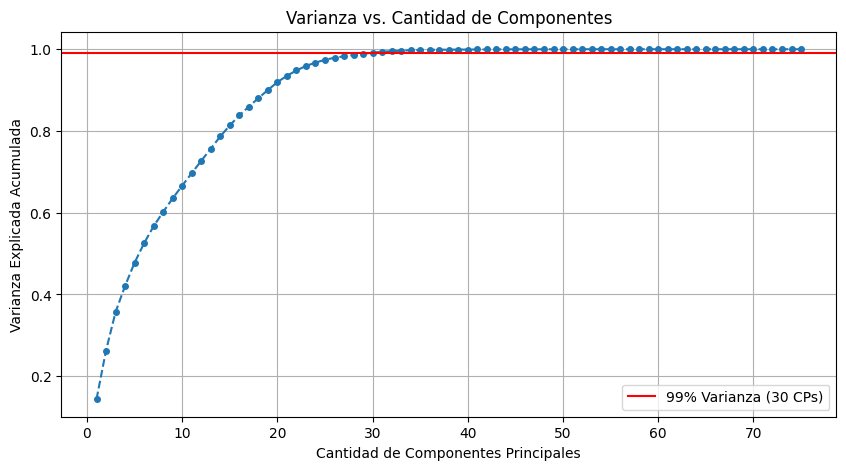

Cantidad de componentes para mantener el 99% de la varianza: 30


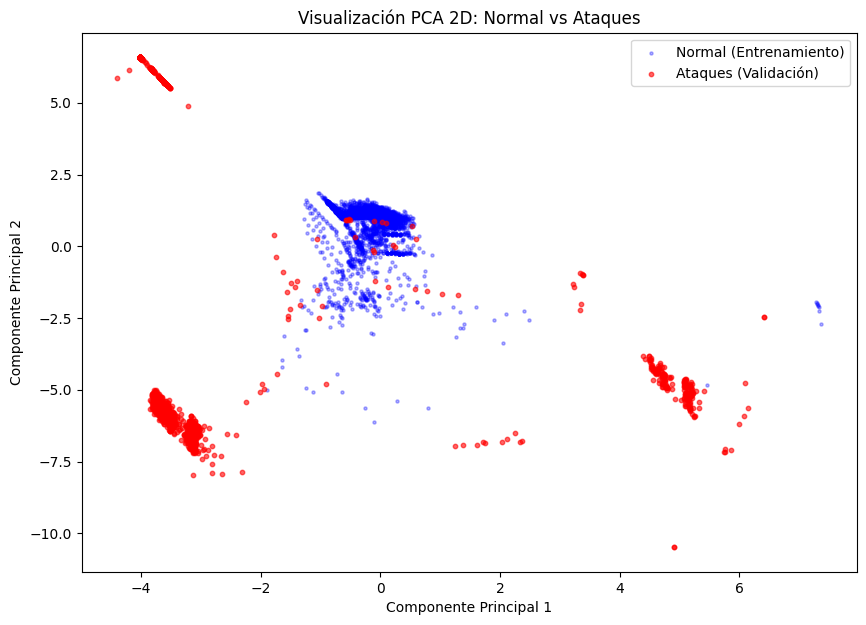

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Aplicar PCA sobre los datos de entrenamiento ya preprocesados
pca_full = PCA().fit(X_train_prep)

# 2. Calcular la varianza acumulada
cum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 3. Determinar cuántos CPs se necesitan para el 99% de la varianza
n_99 = np.argmax(cum_variance >= 0.99) + 1

# Graficar la varianza acumulada
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_variance) + 1), cum_variance, marker='o', linestyle='--', markersize=4)
plt.axhline(y=0.99, color='r', linestyle='-', label=f'99% Varianza ({n_99} CPs)')
plt.xlabel('Cantidad de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza vs. Cantidad de Componentes')
plt.legend()
plt.grid(True)
plt.show()

print(f"Cantidad de componentes para mantener el 99% de la varianza: {n_99}")

# 4. Visualización en 2D para identificar clusters
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_prep)
X_val_2d = pca_2d.transform(X_val_prep)

plt.figure(figsize=(10, 7))
# Graficamos una submuestra de normales para no saturar
plt.scatter(X_train_2d[:5000, 0], X_train_2d[:5000, 1], alpha=0.3, label='Normal (Entrenamiento)', s=5, color='blue')
# Graficamos los ataques de validación
plt.scatter(X_val_2d[y_val==1, 0], X_val_2d[y_val==1, 1], alpha=0.6, label='Ataques (Validación)', s=10, color='red')

plt.title('Visualización PCA 2D: Normal vs Ataques')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.show()

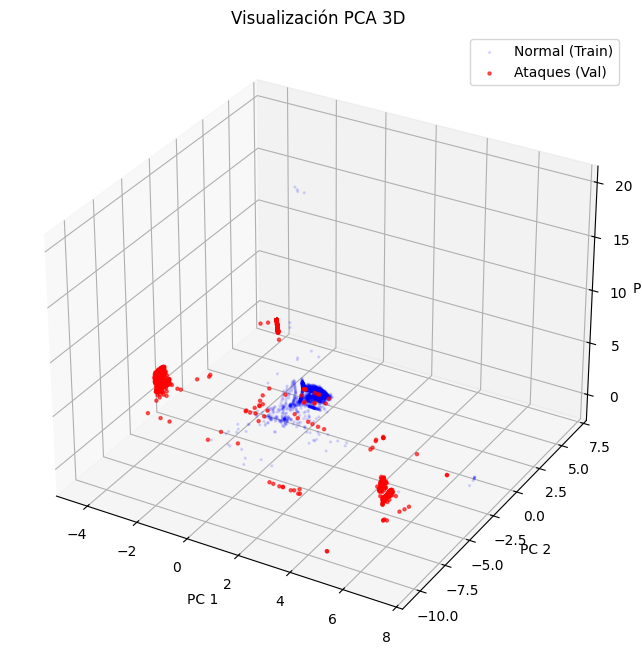

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Aplicar PCA para 3 componentes
pca_3d = PCA(n_components=3)
X_train_3d = pca_3d.fit_transform(X_train_prep)
X_val_3d = pca_3d.transform(X_val_prep)

# 2. Crear la figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficar una submuestra de normales para no saturar
ax.scatter(X_train_3d[:5000, 0], X_train_3d[:5000, 1], X_train_3d[:5000, 2],
           alpha=0.1, label='Normal (Train)', s=2, color='blue')

# Graficar ataques de validación
ax.scatter(X_val_3d[y_val==1, 0], X_val_3d[y_val==1, 1], X_val_3d[y_val==1, 2],
           alpha=0.6, label='Ataques (Val)', s=5, color='red')

ax.set_title('Visualización PCA 3D')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.legend()
plt.show()

### Parte 2

La forma más directa de hacer detección de anomalías utilizando PCA, es mediante el error de reconstrucción. Para esto primero se calculan los componentes principales a partir de los datos de entrenamiento. Luego para cada dato a analizar se lo proyecta sobre estos componentes, y se calcula su reconstrucción. Debido a que los CPs fueron calculado sólo con datos normales, se espera que la reconstrucción de datos anómalos tengan mayores errores. Es por esto que a partir del error de reconstrucción se puede determinar si un dato es anómalo o no.

#### Objetivos:

*   Implementar un detector tal como se describe arriba, utilizando RMSE para calcular el error. El mismo se debe definir como una clase de manera que sea compatible con los *pipelines* de *scikit-learn*. En la siguiente celda se muestra un *template* para crear la clase ([aquí](https://scikit-learn.org/stable/developers/develop.html) se pueden ver otros ejemplos).

*   Crear un *pipeline* que incluya el preprocesamiento y el detector implementado.
*   Entrenar el modelo de manera que mantenga el *99%* de la varianza.
*   Proponga un punto de operación teniendo en cuenta que se quiere evitar un exceso de falsas alarmas. Para ello se recomienda graficar el compromiso entre *precision* y *recall* para distintos valores de *threshold* que definen el punto de operación. Ver la sección *Precision/Recall Trade-off* del capítulo 3 del libro.
*   Graficar los *scores* de los datos utilizados en el punto anterior, diferenciando con colores los datos normales de los anómalos.
*    Evaluar el desempeño en el conjunto de Validación y Test. Puede resultar útil tener la tasa de aciertos por categoría de anomalía.

In [21]:
# Importo las librerías necesarias
from sklearn.base import BaseEstimator, OutlierMixin
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.decomposition import PCA

# Defino la clase AD_PCA que hereda de BaseEstimator y OutlierMixin lo que permite que sea compatible con el pipeline.
# Esta clase debe tener los métodos fit y score.
class AD_PCA(BaseEstimator, OutlierMixin):
    def __init__(self, n_comp=None):
        '''

        Constructor de la clase.

        Parametros:
            n_comp: cantidad de componentes principales a utilizar

        '''

        self.n_comp = n_comp

    def fit(self, X, y=None):
        '''

        Se entrena el modelo.

        Parametros:
            X: matriz de datos
            y: etiquetas (no son necesarias)

        Retorna:
            self: el objeto

        '''

        X = check_array(X)

        self.pca_ = PCA(n_components=self.n_comp)
        self.pca_.fit(X)

        return self

    def score(self, X, y=None):
        '''

        Se calcula el error de reconstrucción de cada muestra.


        Parametros:
            X: matriz de datos
            y: etiquetas (no son necesarias)

        Retorna:
            score: el RMSE de cada muestra reconstruida.

        '''

        # Se verifica que los datos sean válidos
        X = check_array(X)

        # Se verifica que el modelo haya sido entrenado
        check_is_fitted(self, ['pca_'])

        X_proj = self.pca_.transform(X)
        X_recon = self.pca_.inverse_transform(X_proj)
        score = np.sqrt(np.mean((X - X_recon) ** 2, axis=1))
        return score

Componentes retenidos por PCA: 30
Varianza explicada acumulada: 0.9915
Threshold seleccionado: 0.139930
Precision en validacion: 0.9504
Recall en validacion: 0.9639


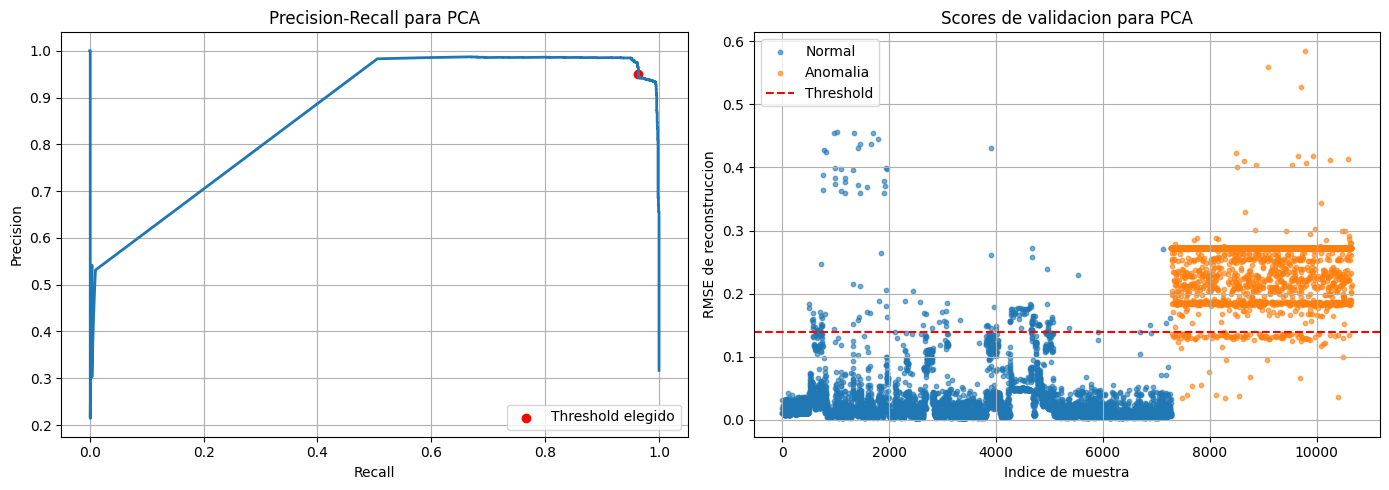

In [22]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import precision_recall_curve, precision_score, recall_score
from sklearn.pipeline import Pipeline

pca_pipeline = Pipeline([
    ('preprocessor', preprocessing_pipeline),
    ('detector', AD_PCA(n_comp=0.99))
])

pca_pipeline.fit(X_train_normal)

detector_pca = pca_pipeline.named_steps['detector']
n_components_pca = detector_pca.pca_.n_components_
explained_variance_pca = detector_pca.pca_.explained_variance_ratio_.sum()

val_scores_pca = pca_pipeline.score(X_val)
test_scores_pca = pca_pipeline.score(X_test)

precision_pca, recall_pca, thresholds_pca = precision_recall_curve(y_val, val_scores_pca)

if len(thresholds_pca) == 0:
    raise ValueError('No se pudo calcular un threshold para PCA en validacion.')

precision_candidates_pca = precision_pca[:-1]
recall_candidates_pca = recall_pca[:-1]
high_precision_mask_pca = precision_candidates_pca >= 0.95

if np.any(high_precision_mask_pca):
    candidate_indices_pca = np.where(high_precision_mask_pca)[0]
    best_idx_pca = candidate_indices_pca[np.argmax(recall_candidates_pca[high_precision_mask_pca])]
else:
    f1_candidates_pca = 2 * precision_candidates_pca * recall_candidates_pca / np.clip(
        precision_candidates_pca + recall_candidates_pca,
        1e-12,
        None,
    )
    best_idx_pca = np.argmax(f1_candidates_pca)

best_threshold_pca = thresholds_pca[best_idx_pca]
y_val_pred_pca = (val_scores_pca > best_threshold_pca).astype(int)
y_test_pred_pca = (test_scores_pca > best_threshold_pca).astype(int)

val_precision_pca = precision_score(y_val, y_val_pred_pca, zero_division=0)
val_recall_pca = recall_score(y_val, y_val_pred_pca, zero_division=0)

print(f'Componentes retenidos por PCA: {n_components_pca}')
print(f'Varianza explicada acumulada: {explained_variance_pca:.4f}')
print(f'Threshold seleccionado: {best_threshold_pca:.6f}')
print(f'Precision en validacion: {val_precision_pca:.4f}')
print(f'Recall en validacion: {val_recall_pca:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recall_pca, precision_pca, linewidth=2)
axes[0].scatter(val_recall_pca, val_precision_pca, color='red', label='Threshold elegido')
axes[0].set_title('Precision-Recall para PCA')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].grid(True)
axes[0].legend()

val_indices = np.arange(len(val_scores_pca))
axes[1].scatter(val_indices[y_val == 0], val_scores_pca[y_val == 0], s=10, alpha=0.6, label='Normal')
axes[1].scatter(val_indices[y_val == 1], val_scores_pca[y_val == 1], s=10, alpha=0.6, label='Anomalia')
axes[1].axhline(best_threshold_pca, color='red', linestyle='--', label='Threshold')
axes[1].set_title('Scores de validacion para PCA')
axes[1].set_xlabel('Indice de muestra')
axes[1].set_ylabel('RMSE de reconstruccion')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

Se otorga una función que, dadas las predicciones, devuelve la tasa de acierto por tipo de anomalía.

In [23]:
def aciertos_por_clase(y, y_pred ,y_g_truth):

    '''

    Parametros:
        y = Etiquetas del conjunto en Formato 0 o 1
        y_pred = Predicciones en el conjunto en Formato True o False
        y_g_truth = Etiquetas del conjunto en formato string indicando el tipo de anomalía.

    Retorna:
        Devuelve un Dataframe con la tasa de aciertos por Clase.

    '''

    aciertos = ( (y_pred.flatten()*1) == y.flatten())
    type_of_anomaly = list(np.unique(y_g_truth))
    acc_class = []

    for i_an in range(len(type_of_anomaly)):
        mask_anomaly  = y_g_truth == type_of_anomaly[i_an]
        total_tipo = np.count_nonzero(mask_anomaly)
        acc_class.append(np.count_nonzero(aciertos & mask_anomaly)/total_tipo)

    return pd.DataFrame([acc_class], columns=type_of_anomaly)

In [24]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_val_cat = y_val_orig.map(attack_dict).fillna('Unknown')
y_test_cat = y_test_orig.map(attack_dict).fillna('Unknown')

metrics_pca = pd.DataFrame(
    {
        'Accuracy': [
            accuracy_score(y_val, y_val_pred_pca),
            accuracy_score(y_test, y_test_pred_pca),
        ],
        'Precision': [
            precision_score(y_val, y_val_pred_pca, zero_division=0),
            precision_score(y_test, y_test_pred_pca, zero_division=0),
        ],
        'Recall': [
            recall_score(y_val, y_val_pred_pca, zero_division=0),
            recall_score(y_test, y_test_pred_pca, zero_division=0),
        ],
        'F1': [
            f1_score(y_val, y_val_pred_pca, zero_division=0),
            f1_score(y_test, y_test_pred_pca, zero_division=0),
        ],
    },
    index=['Validacion', 'Test'],
)

aciertos_val_pca = aciertos_por_clase(np.asarray(y_val), y_val_pred_pca, y_val_cat)
aciertos_test_pca = aciertos_por_clase(np.asarray(y_test), y_test_pred_pca, y_test_cat)

category_order = ['normal', 'DoS', 'Probe', 'R2L', 'U2R', 'Unknown']
aciertos_val_pca = aciertos_val_pca.reindex(columns=[c for c in category_order if c in aciertos_val_pca.columns])
aciertos_test_pca = aciertos_test_pca.reindex(columns=[c for c in category_order if c in aciertos_test_pca.columns])

print('Metricas globales para PCA')
display(metrics_pca.round(4))

print('Tasa de aciertos por categoria - Validacion')
display(aciertos_val_pca.round(4))

print('Tasa de aciertos por categoria - Test')
display(aciertos_test_pca.round(4))


Metricas globales para PCA


,Accuracy,Precision,Recall,F1
Validacion,0.9726,0.9504,0.9639,0.9571
Test,0.8758,0.9910,0.8534,0.9171


Tasa de aciertos por categoria - Validacion


,normal,DoS,Probe,R2L,U2R
0,0.9766,0.9664,0.9697,0.0,0.0


Tasa de aciertos por categoria - Test


,normal,DoS,Probe,R2L,U2R
0,0.9681,0.8907,0.9443,0.3008,0.8904


## K-Means

A continuación se implementará un detector de anomalías utilizando el modelo K-Means.

En la *Parte 1*, se llevará a cabo la determinación del número óptimo de clusters necesarios para el problema. En la *Parte 2* se implementará un detector de anomalías.

Para facilitar la construcción del detector, se sugiere implementar un único pipeline que incluya tanto el preprocesamiento como el modelo.

### Parte 1


#### Ejercicio:

 - Implementar una forma de hallar la cantidad de clusters de K-Means óptima . Se sugiere ver la sección *Finding the optimal number of clusters* del Capítulo 9.

**Comentario**: Emplear alguno de los métodos sugeridos toma un tiempo no menor, se sugiere: (i) economizar las búsquedas, (ii) utilizar semillas, (iii) en cuánto tenga los resultados guardelos en formato *.npy*, *.txt* u otro que considere, para que luego pueda cargar en caso que desee rehacer una gráfica. Seguir esta práctica evita que tenga que volver a correr el experimento.  

K sugerido por silhouette: 5
Silhouette máxima: 0.5855


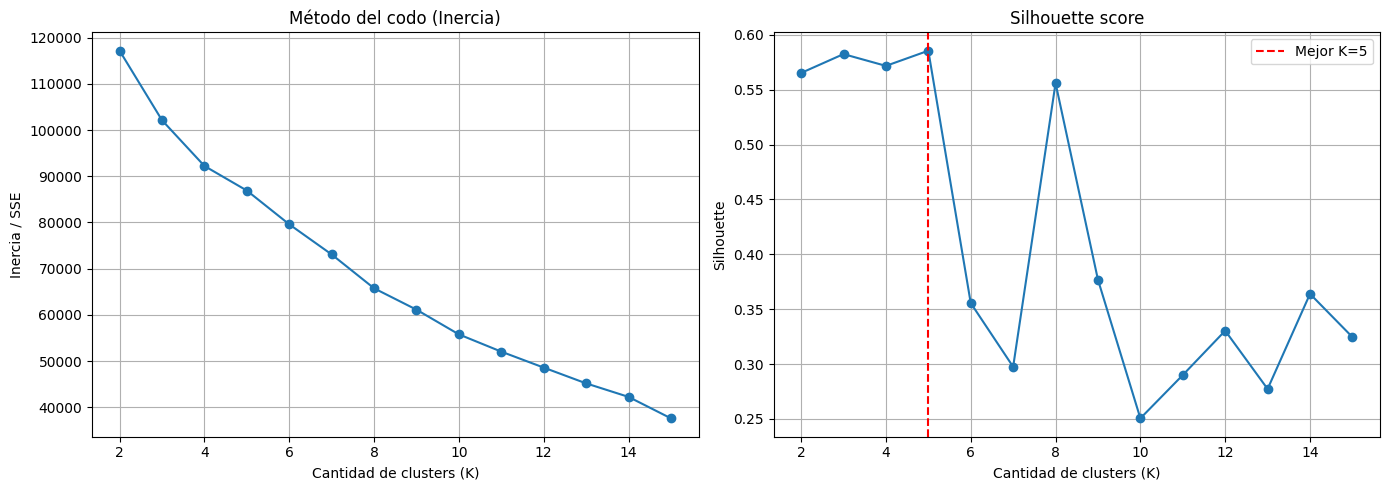

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Buscar K óptimo para K-Means
# --------------------------------------------------

# 1) Trabajar SOLO con entrenamiento normal ya preprocesado
X_kmeans = X_train_prep

# 2) Submuestreo para abaratar el experimento
rng = np.random.default_rng(42)
n_sample = min(5000, X_kmeans.shape[0]) 
idx = rng.choice(X_kmeans.shape[0], size=n_sample, replace=False)
X_sample = X_kmeans[idx]

# 3) Rango de K a explorar
k_values = list(range(2, 16))   # rango acotado 

inertias = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_sample)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, labels_k))

# 4) Guardar resultados para no recomputar
np.save("kmeans_k_values.npy", np.array(k_values))
np.save("kmeans_inertias.npy", np.array(inertias))
np.save("kmeans_silhouette.npy", np.array(sil_scores))

# 5) Elegir K sugerido por silhouette
best_k = k_values[np.argmax(sil_scores)]

print(f"K sugerido por silhouette: {best_k}")
print(f"Silhouette máxima: {max(sil_scores):.4f}")

# 6) Graficar resultados
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(k_values, inertias, marker='o')
ax[0].set_title("Método del codo (Inercia)")
ax[0].set_xlabel("Cantidad de clusters (K)")
ax[0].set_ylabel("Inercia / SSE")
ax[0].grid(True)

ax[1].plot(k_values, sil_scores, marker='o')
ax[1].axvline(best_k, color='red', linestyle='--', label=f'Mejor K={best_k}')
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("Cantidad de clusters (K)")
ax[1].set_ylabel("Silhouette")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

### Parte 2


Una vez seleccionada la cantidad óptima de clusters, se procederá a construir el detector de anomalías utilizando el modelo K-Means. Hay diferentes formas de usar este algoritmo, se sugiere  entrenar el modelo primero y luego calcular la distancia al cluster más cercano. Si esta distancia supera un umbral a definir entonces la muestra se clasificará como anómala.

#### Ejercicios:

- Implementar un detector de anomalías utilizando *K-Means*. Para ello cree una clase y un *pipeline* que lo implemente de forma análoga a lo realizado con el método de PCA.
-   Proponga un punto de operación teniendo en cuenta el compromiso entre *precision* y *recall* para distintos valores de *threshold* que definen el punto de operación.
-   Graficar los *scores* de los datos utilizados en el punto anterior, diferenciando con colores los datos normales de los anómalos.
- Evaluar el desempeño en el conjunto de Validación y Test.

In [26]:
# Importo las bibliotecas necesarias
from sklearn.base import BaseEstimator, OutlierMixin
from sklearn.cluster import KMeans
from sklearn.utils.validation import check_array, check_is_fitted
import numpy as np


# Defino la clase AD_Kmeans que hereda de BaseEstimator y OutlierMixin
class AD_Kmeans(BaseEstimator, OutlierMixin):
    def __init__(self, n_clusters=None, random_state=42, n_init=10):
        '''

            Constructor de la clase.

            Parametros:
                n_clusters: cantidad de clusters a utilizar
                random_state: semilla para reproducibilidad
                n_init: cantidad de inicializaciones

        '''

        self.n_clusters = n_clusters
        self.random_state = random_state
        self.n_init = n_init

    def fit(self, X, y=None):
        '''
            Se entrena el modelo.

            Parametros:
                X: matriz de datos
                y: etiquetas (no son necesarias)

            Retorna:
                self: el objeto
        '''

        X = check_array(X)

        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            n_init=self.n_init
        )
        self.kmeans_.fit(X)

        return self

    def score(self, X, y=None):
        '''

            Se calcula la distancia mínima de cada muestra a los centroides de los clusters.

            Parámetros:
                X: matriz de datos
                y: etiquetas (no son necesarias)

            Retorna:
                d_min: la distancia mínima de cada muestra a los centroides de los clusters.

        '''

        # Se verifica que los datos sean válidos
        X = check_array(X)

        # Se verifica que el modelo haya sido entrenado
        check_is_fitted(self, ['kmeans_'])

        dists = self.kmeans_.transform(X)
        d_min = np.min(dists, axis=1)

        return d_min

Cantidad de clusters usada: 5
Threshold seleccionado: 8.896825
Precision en validacion: 0.9504
Recall en validacion: 0.9882


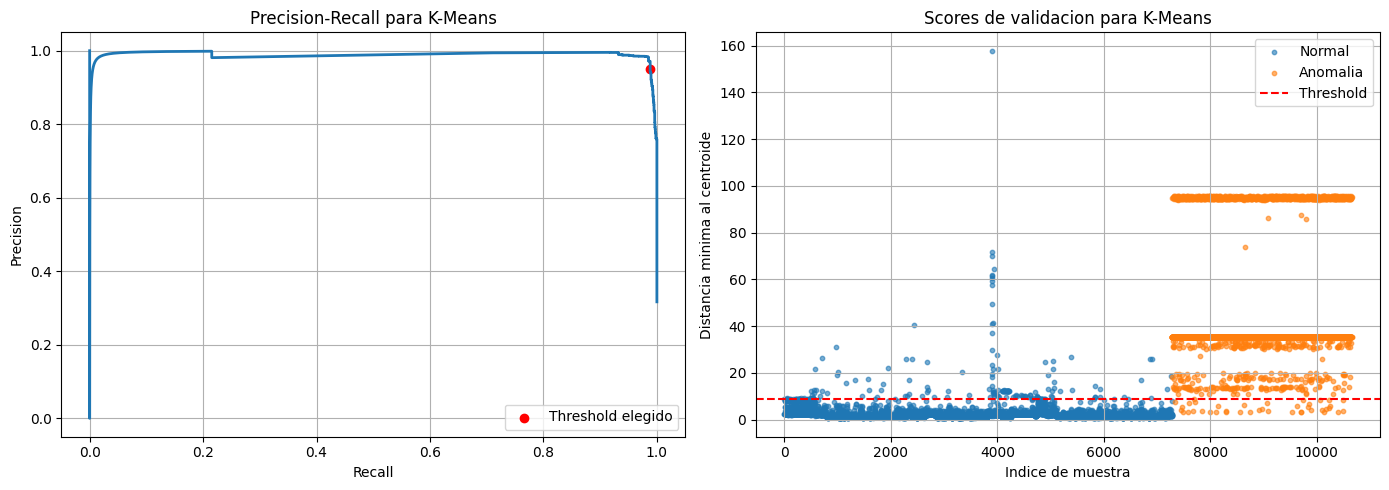

Metricas globales para K-Means


,Accuracy,Precision,Recall,F1
Validacion,0.9799,0.9504,0.9882,0.9689
Test,0.8944,0.9907,0.8771,0.9304


Tasa de aciertos por categoria - Validacion


,normal,DoS,Probe,R2L,U2R
0,0.9761,0.9925,0.7273,0.375,0.0


Tasa de aciertos por categoria - Test


,normal,DoS,Probe,R2L,U2R
0,0.9659,0.9336,0.868,0.0863,0.2851


In [27]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score
)
from sklearn.pipeline import Pipeline

kmeans_pipeline = Pipeline([
    ('preprocessor', preprocessing_pipeline),
    ('detector', AD_Kmeans(n_clusters=best_k, random_state=42, n_init=10))
])

# Entrenar SOLO con datos normales
kmeans_pipeline.fit(X_train_normal)

detector_kmeans = kmeans_pipeline.named_steps['detector']

val_scores_kmeans = kmeans_pipeline.score(X_val)
test_scores_kmeans = kmeans_pipeline.score(X_test)

precision_kmeans, recall_kmeans, thresholds_kmeans = precision_recall_curve(y_val, val_scores_kmeans)

if len(thresholds_kmeans) == 0:
    raise ValueError('No se pudo calcular un threshold para K-Means en validacion.')

precision_candidates_kmeans = precision_kmeans[:-1]
recall_candidates_kmeans = recall_kmeans[:-1]

high_precision_mask_kmeans = precision_candidates_kmeans >= 0.95

if np.any(high_precision_mask_kmeans):
    candidate_indices_kmeans = np.where(high_precision_mask_kmeans)[0]
    best_idx_kmeans = candidate_indices_kmeans[
        np.argmax(recall_candidates_kmeans[high_precision_mask_kmeans])
    ]
else:
    f1_candidates_kmeans = 2 * precision_candidates_kmeans * recall_candidates_kmeans / np.clip(
        precision_candidates_kmeans + recall_candidates_kmeans,
        1e-12,
        None
    )
    best_idx_kmeans = np.argmax(f1_candidates_kmeans)

best_threshold_kmeans = thresholds_kmeans[best_idx_kmeans]

y_val_pred_kmeans = (val_scores_kmeans > best_threshold_kmeans).astype(int)
y_test_pred_kmeans = (test_scores_kmeans > best_threshold_kmeans).astype(int)

val_precision_kmeans = precision_score(y_val, y_val_pred_kmeans, zero_division=0)
val_recall_kmeans = recall_score(y_val, y_val_pred_kmeans, zero_division=0)

print(f'Cantidad de clusters usada: {detector_kmeans.n_clusters}')
print(f'Threshold seleccionado: {best_threshold_kmeans:.6f}')
print(f'Precision en validacion: {val_precision_kmeans:.4f}')
print(f'Recall en validacion: {val_recall_kmeans:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recall_kmeans, precision_kmeans, linewidth=2)
axes[0].scatter(val_recall_kmeans, val_precision_kmeans, color='red', label='Threshold elegido')
axes[0].set_title('Precision-Recall para K-Means')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].grid(True)
axes[0].legend()

val_indices = np.arange(len(val_scores_kmeans))
axes[1].scatter(val_indices[y_val == 0], val_scores_kmeans[y_val == 0], s=10, alpha=0.6, label='Normal')
axes[1].scatter(val_indices[y_val == 1], val_scores_kmeans[y_val == 1], s=10, alpha=0.6, label='Anomalia')
axes[1].axhline(best_threshold_kmeans, color='red', linestyle='--', label='Threshold')
axes[1].set_title('Scores de validacion para K-Means')
axes[1].set_xlabel('Indice de muestra')
axes[1].set_ylabel('Distancia minima al centroide')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluacion final
y_val_cat = y_val_orig.map(attack_dict).fillna('Unknown')
y_test_cat = y_test_orig.map(attack_dict).fillna('Unknown')

metrics_kmeans = pd.DataFrame(
    {
        'Accuracy': [
            accuracy_score(y_val, y_val_pred_kmeans),
            accuracy_score(y_test, y_test_pred_kmeans),
        ],
        'Precision': [
            precision_score(y_val, y_val_pred_kmeans, zero_division=0),
            precision_score(y_test, y_test_pred_kmeans, zero_division=0),
        ],
        'Recall': [
            recall_score(y_val, y_val_pred_kmeans, zero_division=0),
            recall_score(y_test, y_test_pred_kmeans, zero_division=0),
        ],
        'F1': [
            f1_score(y_val, y_val_pred_kmeans, zero_division=0),
            f1_score(y_test, y_test_pred_kmeans, zero_division=0),
        ],
    },
    index=['Validacion', 'Test'],
)

aciertos_val_kmeans = aciertos_por_clase(np.asarray(y_val), y_val_pred_kmeans, y_val_cat)
aciertos_test_kmeans = aciertos_por_clase(np.asarray(y_test), y_test_pred_kmeans, y_test_cat)

category_order = ['normal', 'DoS', 'Probe', 'R2L', 'U2R', 'Unknown']
aciertos_val_kmeans = aciertos_val_kmeans.reindex(columns=[c for c in category_order if c in aciertos_val_kmeans.columns])
aciertos_test_kmeans = aciertos_test_kmeans.reindex(columns=[c for c in category_order if c in category_order if c in aciertos_test_kmeans.columns])

print('Metricas globales para K-Means')
display(metrics_kmeans.round(4))

print('Tasa de aciertos por categoria - Validacion')
display(aciertos_val_kmeans.round(4))

print('Tasa de aciertos por categoria - Test')
display(aciertos_test_kmeans.round(4))

## Gaussian Mixtures Models

Por último, se implementará un detector de anomalías utilizando el modelo mezcla de gaussianas (GMM).

En la *Parte 1*, se llevará a cabo la determinación del número óptimo de clusters necesarios para el problema. Una vez seleccionado el número adecuado de clusters, se procederá a la construcción del clasificador en la *Parte 2*.

Nuevamente, para facilitar la construcción del detector, se sugiere implementar un único pipeline que incluya tanto el preprocesamiento como el modelo.

### Parte 1


Siga el ejemplo de la sección *Anomaly Detection Using Gaussian Mixture* en el Capítulo 9 del libro, y determine la cantidad óptima de mezclas a utilizar por el modelo.


#### Ejercicio:

 - Proponer una forma de hallar la cantidad óptima de mezclas a utilizar.

 **Comentario**: Emplear alguno de los métodos sugeridos toma un tiempo no menor, se sugiere: (i) economizar las búsquedas, (ii) utilizar semillas, (iii) en cuánto tenga los resultados guardelos en formato *.npy*, *.txt* u otro que considere, para que luego pueda cargar en caso que desee rehacer una gráfica. Seguir esta práctica evita que tenga que volver a correr el experimento.  

Mejor configuración según BIC:
n_components = 10
covariance_type = diag
BIC = -3423206.18
AIC = -3433040.62


,covariance_type,n_components,bic,aic
0,diag,10,-3.423206e+06,-3.433041e+06
1,full,5,-3.218532e+06,-3.313872e+06
2,full,10,-3.192594e+06,-3.383280e+06
3,full,9,-3.169858e+06,-3.341475e+06
4,full,6,-3.136699e+06,-3.251108e+06
5,full,8,-3.114477e+06,-3.267024e+06
6,full,7,-3.103527e+06,-3.237005e+06
7,diag,7,-3.052625e+06,-3.059507e+06
8,full,4,-2.994494e+06,-3.070765e+06
9,diag,8,-2.942001e+06,-2.949868e+06


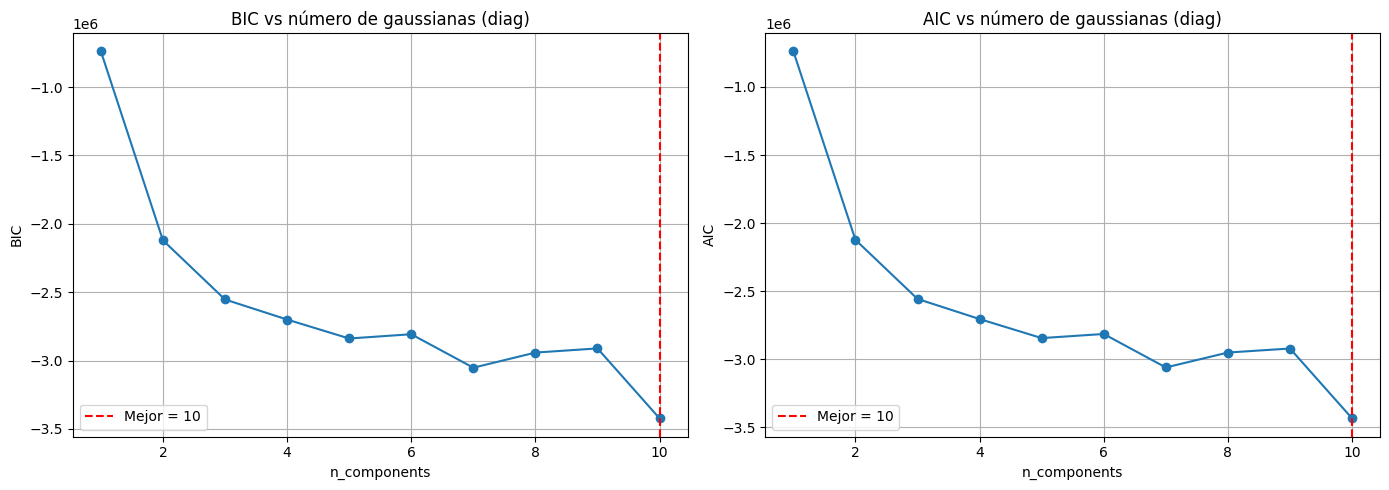

In [28]:
from sklearn.mixture import GaussianMixture
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datos de entrenamiento normales ya preprocesados
X_gmm = X_train_prep

# Opcional: submuestreo para que no demore demasiado
rng = np.random.default_rng(42)
n_sample = min(5000, X_gmm.shape[0])
idx = rng.choice(X_gmm.shape[0], size=n_sample, replace=False)
X_sample = X_gmm[idx]

# Rango de componentes y tipos de covarianza a explorar
n_components_range = range(1, 11) # se probo con 30, se tomo 29 pero empeoro como detector. 
covariance_types = ["full", "tied", "diag", "spherical"]

results = []

for cov_type in covariance_types:
    for n_comp in n_components_range:
        gm = GaussianMixture(
            n_components=n_comp,
            covariance_type=cov_type,
            n_init=5,
            random_state=42
        )
        gm.fit(X_sample)

        results.append({
            "covariance_type": cov_type,
            "n_components": n_comp,
            "bic": gm.bic(X_sample),
            "aic": gm.aic(X_sample)
        })

results_df = pd.DataFrame(results)

# Mejor modelo según BIC
best_idx = results_df["bic"].idxmin()
best_row = results_df.loc[best_idx]

best_n_components = int(best_row["n_components"])
best_covariance_type = best_row["covariance_type"]

print("Mejor configuración según BIC:")
print(f"n_components = {best_n_components}")
print(f"covariance_type = {best_covariance_type}")
print(f"BIC = {best_row['bic']:.2f}")
print(f"AIC = {best_row['aic']:.2f}")

display(results_df.sort_values("bic").reset_index(drop=True))

# Graficar BIC y AIC para el mejor covariance_type
best_cov_df = results_df[results_df["covariance_type"] == best_covariance_type].sort_values("n_components")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(best_cov_df["n_components"], best_cov_df["bic"], marker="o")
ax[0].axvline(best_n_components, color="red", linestyle="--", label=f"Mejor = {best_n_components}")
ax[0].set_title(f"BIC vs número de gaussianas ({best_covariance_type})")
ax[0].set_xlabel("n_components")
ax[0].set_ylabel("BIC")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(best_cov_df["n_components"], best_cov_df["aic"], marker="o")
ax[1].axvline(best_n_components, color="red", linestyle="--", label=f"Mejor = {best_n_components}")
ax[1].set_title(f"AIC vs número de gaussianas ({best_covariance_type})")
ax[1].set_xlabel("n_components")
ax[1].set_ylabel("AIC")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()


### Parte 2

Siguiendo también el el ejemplo de la sección *Anomaly Detection Using Gaussian Mixture* en el Capítulo 9 del libro, construya y entrene un clasificador de anomalías utilizando la cantidad de mezclas determinadas en la parte anterior.

Una vez entrenado el modelo, se calcula la log-verosimilitud de cada muestra y se umbraliza para detectar anomalías. Si el valor de la log-verosimilitud es menor que un umbral determinado, se considera que la muestra es anómala.

El valor del umbral se fija a partir de determinar la proporción de muestras que se clasifican como anómalas. Por ejemplo, si se sabe de antemano que los ataques constituyen un porcentaje $\alpha$ de las muestras, se puede calcular el valor que define el percentil correspondiente a este $\alpha$% en la escala de log-verosimilitud para clasificar las muestras como anómalas.


#### Ejercicios:

*   Implementar un detector que calcule el valor de los *scores*, la log-verosimilitud en este caso. En la siguiente celda se proporciona un *template* para la implementación del detector.
*   Fijar un umbral en validación utilizando algún percentil similar a lo realizado en el Capítulo 9 del libro. Se obtendrán distintos puntos de funcionamiento en función del percentil elegido. Discutir sobre los resultados obtenidos.
*   Evaluar el desempeño en el conjunto de Validación y Test.

In [29]:
# Importo las bibliotecas necesarias
from sklearn.mixture import GaussianMixture
from sklearn.base import BaseEstimator, OutlierMixin
from sklearn.utils.validation import check_array, check_is_fitted


# Defino la clase AD_GMM que hereda de BaseEstimator y OutlierMixin lo que permite que sea compatible con el pipeline.
# Esta clase debe tener los métodos fit y score.
class AD_GMM(BaseEstimator, OutlierMixin):
    def __init__(self, n_comp=None, covariance_type='full', random_state=42, n_init=5):
        '''

            Constructor de la clase.

            Parametros:
                n_comp: cantidad de mezclas a utilizar
                covariance_type: tipo de covarianza del modelo
                random_state: semilla para reproducibilidad
                n_init: cantidad de inicializaciones

        '''

        self.n_comp = n_comp
        self.covariance_type = covariance_type
        self.random_state = random_state
        self.n_init = n_init

    def fit(self, X, y=None):
        '''

            Se entrena el modelo.

            Parametros:
                X: matriz de datos
                y: etiquetas (no son necesarias)

            Retorna:
                self: el objeto

        '''

        X = check_array(X)

        self.gmm_ = GaussianMixture(
            n_components=self.n_comp,
            covariance_type=self.covariance_type,
            random_state=self.random_state,
            n_init=self.n_init
        )
        self.gmm_.fit(X)

        return self

    def score(self, X, y=None):
        '''

            Se calcula la log-verosimilitud de cada muestra.

            Parametros:
                X: matriz de datos
                y: etiquetas (no son necesarias)

            Retorna:
                score: el score de cada muestra.

        '''

        # Se verifica que los datos sean válidos
        X = check_array(X)

        # Se verifica que el modelo haya sido entrenado
        check_is_fitted(self, ['gmm_'])

        score = self.gmm_.score_samples(X)

        return score

Cantidad de mezclas usada: 10
covariance_type usado: diag
Percentil seleccionado: 30.0
Threshold seleccionado: -3040.268588
Precision en validacion: 0.9991
Recall en validacion: 0.9458


,percentil,threshold,precision,recall,f1
15,8.0,-499994.0856,1.0,0.2526,0.4033
14,7.5,-500004.3279,1.0,0.2369,0.3831
13,7.0,-500042.3266,1.0,0.2209,0.3619
12,6.5,-500050.1382,1.0,0.2049,0.3401
11,6.0,-500052.1970,1.0,0.1895,0.3186
10,5.5,-500055.0667,1.0,0.1735,0.2957
9,5.0,-500057.6425,1.0,0.1578,0.2726
8,4.5,-500060.7773,1.0,0.1421,0.2489
7,4.0,-500069.1420,1.0,0.1264,0.2245
6,3.5,-500093.3887,1.0,0.1105,0.1989


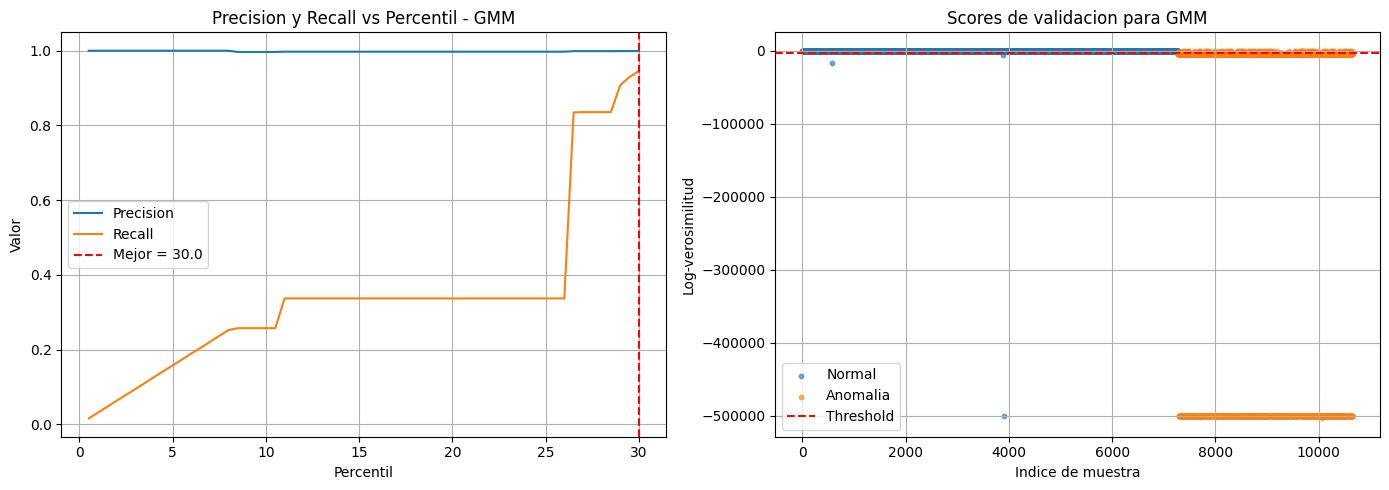

Metricas globales para GMM


,Accuracy,Precision,Recall,F1
Validacion,0.9825,0.9991,0.9458,0.9717
Test,0.7970,0.9997,0.7481,0.8558


Tasa de aciertos por categoria - Validacion


,normal,DoS,Probe,R2L,U2R
0,0.9996,0.955,0.2727,0.0,0.0


Tasa de aciertos por categoria - Test


,normal,DoS,Probe,R2L,U2R
0,0.9991,0.8119,0.1651,0.0008,0.1009


In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline

# Uso la mejor configuración encontrada en la Parte 1
gmm_pipeline = Pipeline([
    ('preprocessor', preprocessing_pipeline),
    ('detector', AD_GMM(
        n_comp=best_n_components,
        covariance_type=best_covariance_type,
        random_state=42,
        n_init=5
    ))
])

# Entrenar con datos normales
gmm_pipeline.fit(X_train_normal)

detector_gmm = gmm_pipeline.named_steps['detector']

# Scores: log-verosimilitud
# Score más bajo => más anómalo
val_scores_gmm = gmm_pipeline.score(X_val)
test_scores_gmm = gmm_pipeline.score(X_test)

# Búsqueda del punto de operación usando percentiles
percentiles = np.arange(0.5, 30.5, 0.5)

rows = []

for p in percentiles:
    thr = np.percentile(val_scores_gmm, p)
    y_val_pred_tmp = (val_scores_gmm < thr).astype(int)

    prec = precision_score(y_val, y_val_pred_tmp, zero_division=0)
    rec = recall_score(y_val, y_val_pred_tmp, zero_division=0)
    f1 = f1_score(y_val, y_val_pred_tmp, zero_division=0)

    rows.append({
        'percentil': p,
        'threshold': thr,
        'precision': prec,
        'recall': rec,
        'f1': f1
    })

percentil_results_gmm = pd.DataFrame(rows)

# Elegir percentil priorizando precision alta
high_precision_mask_gmm = percentil_results_gmm['precision'] >= 0.95

if high_precision_mask_gmm.any():
    best_idx_gmm = percentil_results_gmm.loc[high_precision_mask_gmm, 'recall'].idxmax()
else:
    best_idx_gmm = percentil_results_gmm['f1'].idxmax()

best_percentile_gmm = percentil_results_gmm.loc[best_idx_gmm, 'percentil']
best_threshold_gmm = percentil_results_gmm.loc[best_idx_gmm, 'threshold']

# Predicciones finales
y_val_pred_gmm = (val_scores_gmm < best_threshold_gmm).astype(int)
y_test_pred_gmm = (test_scores_gmm < best_threshold_gmm).astype(int)

val_precision_gmm = precision_score(y_val, y_val_pred_gmm, zero_division=0)
val_recall_gmm = recall_score(y_val, y_val_pred_gmm, zero_division=0)

print(f'Cantidad de mezclas usada: {detector_gmm.n_comp}')
print(f'covariance_type usado: {detector_gmm.covariance_type}')
print(f'Percentil seleccionado: {best_percentile_gmm:.1f}')
print(f'Threshold seleccionado: {best_threshold_gmm:.6f}')
print(f'Precision en validacion: {val_precision_gmm:.4f}')
print(f'Recall en validacion: {val_recall_gmm:.4f}')

display(percentil_results_gmm.sort_values(['precision', 'recall', 'f1'], ascending=False).head(10).round(4))

# Graficas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision y recall vs percentil
axes[0].plot(percentil_results_gmm['percentil'], percentil_results_gmm['precision'], label='Precision')
axes[0].plot(percentil_results_gmm['percentil'], percentil_results_gmm['recall'], label='Recall')
axes[0].axvline(best_percentile_gmm, color='red', linestyle='--', label=f'Mejor = {best_percentile_gmm:.1f}')
axes[0].set_title('Precision y Recall vs Percentil - GMM')
axes[0].set_xlabel('Percentil')
axes[0].set_ylabel('Valor')
axes[0].grid(True)
axes[0].legend()

# Scores diferenciando normales y anomalías
val_indices = np.arange(len(val_scores_gmm))
axes[1].scatter(val_indices[y_val == 0], val_scores_gmm[y_val == 0], s=10, alpha=0.6, label='Normal')
axes[1].scatter(val_indices[y_val == 1], val_scores_gmm[y_val == 1], s=10, alpha=0.6, label='Anomalia')
axes[1].axhline(best_threshold_gmm, color='red', linestyle='--', label='Threshold')
axes[1].set_title('Scores de validacion para GMM')
axes[1].set_xlabel('Indice de muestra')
axes[1].set_ylabel('Log-verosimilitud')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluacion final
y_val_cat = y_val_orig.map(attack_dict).fillna('Unknown')
y_test_cat = y_test_orig.map(attack_dict).fillna('Unknown')

metrics_gmm = pd.DataFrame(
    {
        'Accuracy': [
            accuracy_score(y_val, y_val_pred_gmm),
            accuracy_score(y_test, y_test_pred_gmm),
        ],
        'Precision': [
            precision_score(y_val, y_val_pred_gmm, zero_division=0),
            precision_score(y_test, y_test_pred_gmm, zero_division=0),
        ],
        'Recall': [
            recall_score(y_val, y_val_pred_gmm, zero_division=0),
            recall_score(y_test, y_test_pred_gmm, zero_division=0),
        ],
        'F1': [
            f1_score(y_val, y_val_pred_gmm, zero_division=0),
            f1_score(y_test, y_test_pred_gmm, zero_division=0),
        ],
    },
    index=['Validacion', 'Test'],
)

aciertos_val_gmm = aciertos_por_clase(np.asarray(y_val), y_val_pred_gmm, y_val_cat)
aciertos_test_gmm = aciertos_por_clase(np.asarray(y_test), y_test_pred_gmm, y_test_cat)

category_order = ['normal', 'DoS', 'Probe', 'R2L', 'U2R', 'Unknown']
aciertos_val_gmm = aciertos_val_gmm.reindex(columns=[c for c in category_order if c in aciertos_val_gmm.columns])
aciertos_test_gmm = aciertos_test_gmm.reindex(columns=[c for c in category_order if c in aciertos_test_gmm.columns])

print('Metricas globales para GMM')
display(metrics_gmm.round(4))

print('Tasa de aciertos por categoria - Validacion')
display(aciertos_val_gmm.round(4))

print('Tasa de aciertos por categoria - Test')
display(aciertos_test_gmm.round(4))

## Comparación de Modelos

En esta sección se comparan los resultados obtenidos con **PCA**, **K-Means** y **GMM** utilizando las métricas globales en validación y test, así como la tasa de aciertos por categoría de anomalía.

Comparacion global en Validacion


,Accuracy,Precision,Recall,F1
PCA,0.9726,0.9504,0.9639,0.9571
K-Means,0.9799,0.9504,0.9882,0.9689
GMM,0.9825,0.9991,0.9458,0.9717


Comparacion global en Test


,Accuracy,Precision,Recall,F1
PCA,0.8758,0.9910,0.8534,0.9171
K-Means,0.8944,0.9907,0.8771,0.9304
GMM,0.7970,0.9997,0.7481,0.8558


Acierto por categoria en Test


,normal,DoS,Probe,R2L,U2R
PCA,0.9681,0.8907,0.9443,0.3008,0.8904
K-Means,0.9659,0.9336,0.8680,0.0863,0.2851
GMM,0.9991,0.8119,0.1651,0.0008,0.1009


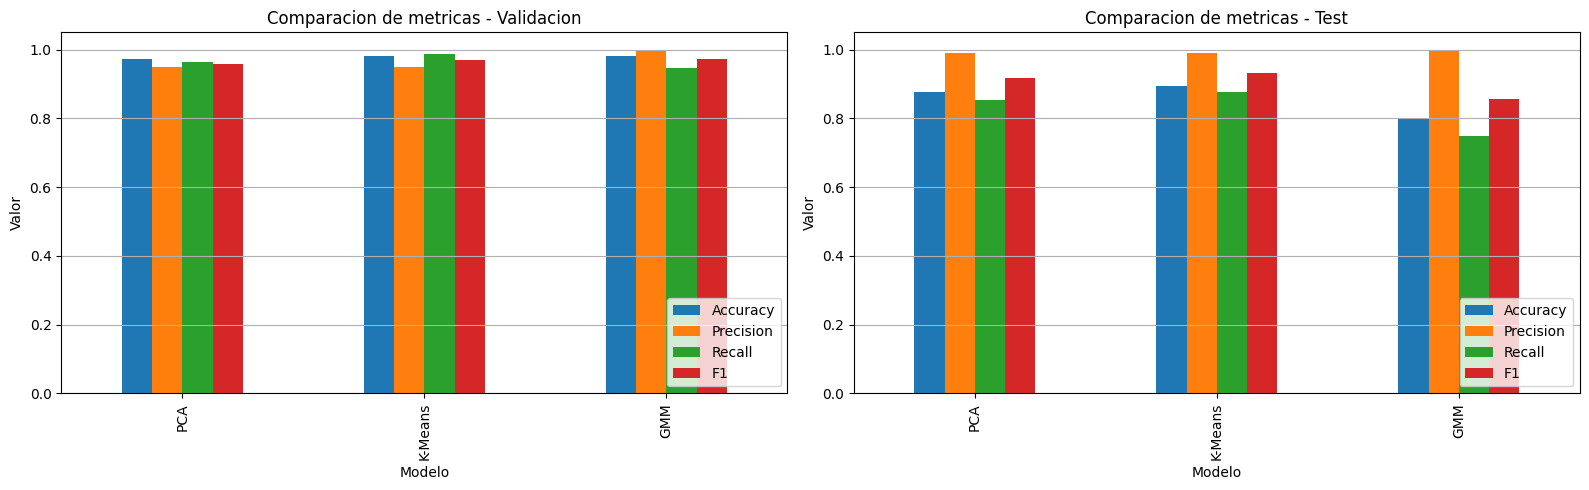

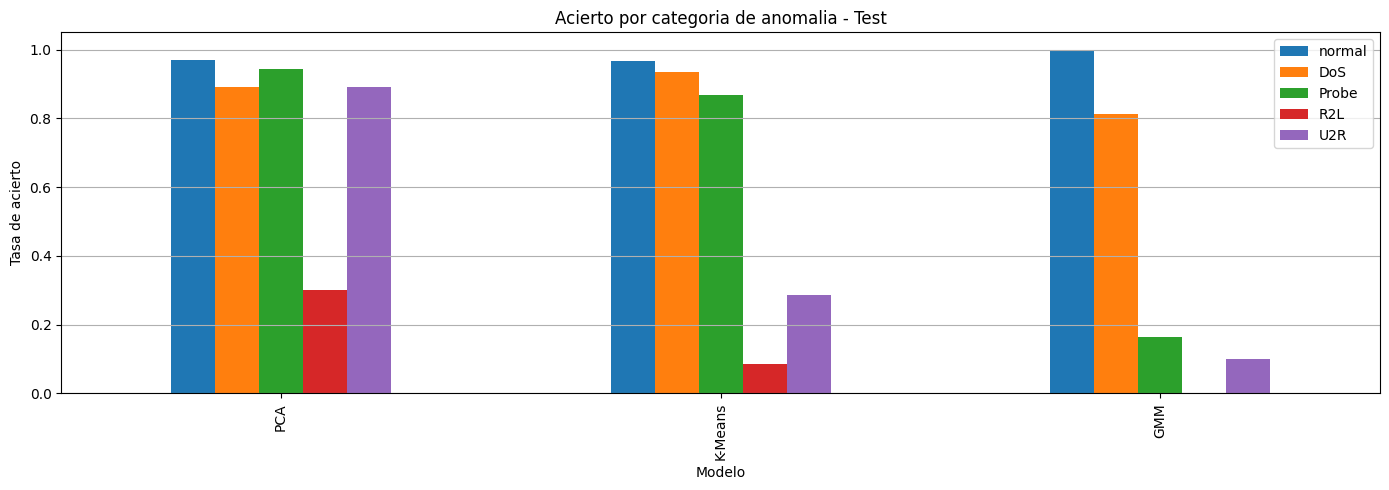

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

model_names = ['PCA', 'K-Means', 'GMM']
metric_columns = ['Accuracy', 'Precision', 'Recall', 'F1']

comparison_metrics_val = pd.DataFrame(
    [
        metrics_pca.loc['Validacion', metric_columns],
        metrics_kmeans.loc['Validacion', metric_columns],
        metrics_gmm.loc['Validacion', metric_columns],
    ],
    index=model_names,
)

comparison_metrics_test = pd.DataFrame(
    [
        metrics_pca.loc['Test', metric_columns],
        metrics_kmeans.loc['Test', metric_columns],
        metrics_gmm.loc['Test', metric_columns],
    ],
    index=model_names,
)

category_order = ['normal', 'DoS', 'Probe', 'R2L', 'U2R', 'Unknown']
all_categories = set(aciertos_test_pca.columns) | set(aciertos_test_kmeans.columns) | set(aciertos_test_gmm.columns)
category_columns = [c for c in category_order if c in all_categories]
category_columns += [c for c in sorted(all_categories) if c not in category_columns]

comparison_categories_test = pd.DataFrame(
    [
        aciertos_test_pca.reindex(columns=category_columns).iloc[0],
        aciertos_test_kmeans.reindex(columns=category_columns).iloc[0],
        aciertos_test_gmm.reindex(columns=category_columns).iloc[0],
    ],
    index=model_names,
)

print('Comparacion global en Validacion')
display(comparison_metrics_val.round(4))

print('Comparacion global en Test')
display(comparison_metrics_test.round(4))

print('Acierto por categoria en Test')
display(comparison_categories_test.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

comparison_metrics_val.plot(kind='bar', ax=axes[0])
axes[0].set_title('Comparacion de metricas - Validacion')
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('Valor')
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, axis='y')
axes[0].legend(loc='lower right')

comparison_metrics_test.plot(kind='bar', ax=axes[1])
axes[1].set_title('Comparacion de metricas - Test')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Valor')
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, axis='y')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

ax = comparison_categories_test.plot(kind='bar', figsize=(14, 5))
ax.set_title('Acierto por categoria de anomalia - Test')
ax.set_xlabel('Modelo')
ax.set_ylabel('Tasa de acierto')
ax.set_ylim(0, 1.05)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()
